In [1]:
!pip install -qU pip setuptools wheel
!pip install -qU spacy
!pip install -qU googletrans==4.0.0-rc1
!python -m spacy download zh_core_web_sm
# !python -m spacy download zh_core_web_md
# !python -m spacy download zh_core_web_lg
# !python -m spacy download zh_core_web_trf

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.1/29.1 MB 79.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 69.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.5/19.5 MB 81.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 91.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cudf-cu12 24.6.1 requires numpy<2.0a0,>=1.23, but you have numpy 2.0.2 which is incompatible.
cupy-cuda12x 12.2.0 requires numpy<1.27,>=1.20, but you have numpy 2.0.2 which is incompatible.
en-core-web-sm 3.7.1 requires spacy<3.8.0,>=3.7.2, but you have spacy 3.8.2 which is inc

### 加載語言模型

In [2]:
import spacy

nlp_en = spacy.load("en_core_web_sm")
nlp_zh = spacy.load("zh_core_web_sm")

/usr/local/lib/python3.10/dist-packages/spacy/util.py:910: UserWarning: [W095] Model 'en_core_web_sm' (3.7.1) was trained with spaCy v3.7.2 and may not be 100% compatible with the current version (3.8.2). If you see errors or degraded performance, download a newer compatible model or retrain your custom model with the current spaCy version. For more details and available updates, run: python -m spacy validate
  warnings.warn(warn_msg)


In [3]:
from googletrans import Translator
translator = Translator()

####句子

In [4]:
test_sentence = {
  "sentences": [
    "張三在台北101前面拍了很多照片。",
    "李四昨天在台中火車站迷路了。",
    "王五參加了鴻海公司的年度大會。",
    "華為手機在全球市場上的銷量持續增長。",
    "張三開了一間叫做「香格里拉」的餐廳。",
    "小明帶著他的iPhone去了華山藝文中心。",
    "你知道Apple的總部在哪裡嗎？",
    "昨天在星巴克遇見了老朋友林小明。",
    "上海是中國的經濟中心。",
    "Google正在開發一個新的AI模型。",
    "馬雲創辦的阿里巴巴是中國最大的電商平台之一。",
    "珠穆朗瑪峰是世界最高的山。",
    "高雄的六合夜市是美食愛好者的天堂。",
    "臺灣大學的學生來參加這次比賽。",
    "蘋果電腦的發明改變了整個科技產業。",
    "中國移動的用戶數量每年都在增加。",
    "香港的金融市場非常活躍。",
    "IBM推出了一款全新的量子計算機。",
    "Microsoft的Windows系統是全球最常用的作業系統之一。",
    "劉德華出演了很多經典的電影。",
    "台灣的玉山是當地最高的山峰。",
    "世界衛生組織在日內瓦總部召開會議。",
    "任天堂的Switch遊戲機在全球大受歡迎。",
    "中央電視台播放了關於新冠疫情的最新報導。",
    "奧林匹克運動會將在東京舉行。",
    "特斯拉的自動駕駛技術引發了廣泛關注。",
    "小紅書是一個非常受歡迎的社交平台。",
    "Facebook的隱私政策再次引發爭議。",
    "日本的富士山每年都吸引大量遊客。",
    "李小龍的武術精神影響了全世界。"
  ]
}

#### 翻譯

In [14]:
source_sentence = test_sentence['sentences'][14]
current_translation = translator.translate(source_sentence, src = "zh-TW", dest='en')
transtext = current_translation.text
transtext

'The invention of Apple Computer has changed the entire technology industry.'

####使用 spaCy 進行分詞

In [15]:
doc_zh = nlp_zh(source_sentence)
doc_en = nlp_en(transtext)

# 輸出分詞結果
tokens_zh = [token.text for token in doc_zh]
tokens_en = [token.text for token in doc_en]

print(tokens_zh)
print(tokens_en)

['蘋果', '電腦', '的', '發明', '改變', '了', '整個', '科技', '產業', '。']
['The', 'invention', 'of', 'Apple', 'Computer', 'has', 'changed', 'the', 'entire', 'technology', 'industry', '.']


#### 處理一下專有名詞

In [11]:
term_translation_map = {
    'Kaohsiung': '高雄',
    'Liuhe Night Market': '六合夜市',
}

##Word Alignment

#### 手動

In [16]:
# 定義對應關係 (中文索引 -> 英文索引)
alignment = {
    0: [3],      # 蘋果 -> Apple
    1: [4],      # 電腦 -> Computer
    2: [2],      # 的 -> of
    3: [1],      # 發明 -> invention
    4: [6],      # 改變 -> changed
    5: [5],      # 了 -> has
    6: [8],      # 整個 -> entire
    7: [9],      # 科技 -> technology
    8: [10],     # 產業 -> industry
    9: []        # 。 -> .
}

#### 讓 chatgpt-4o 幫我列出對應關係

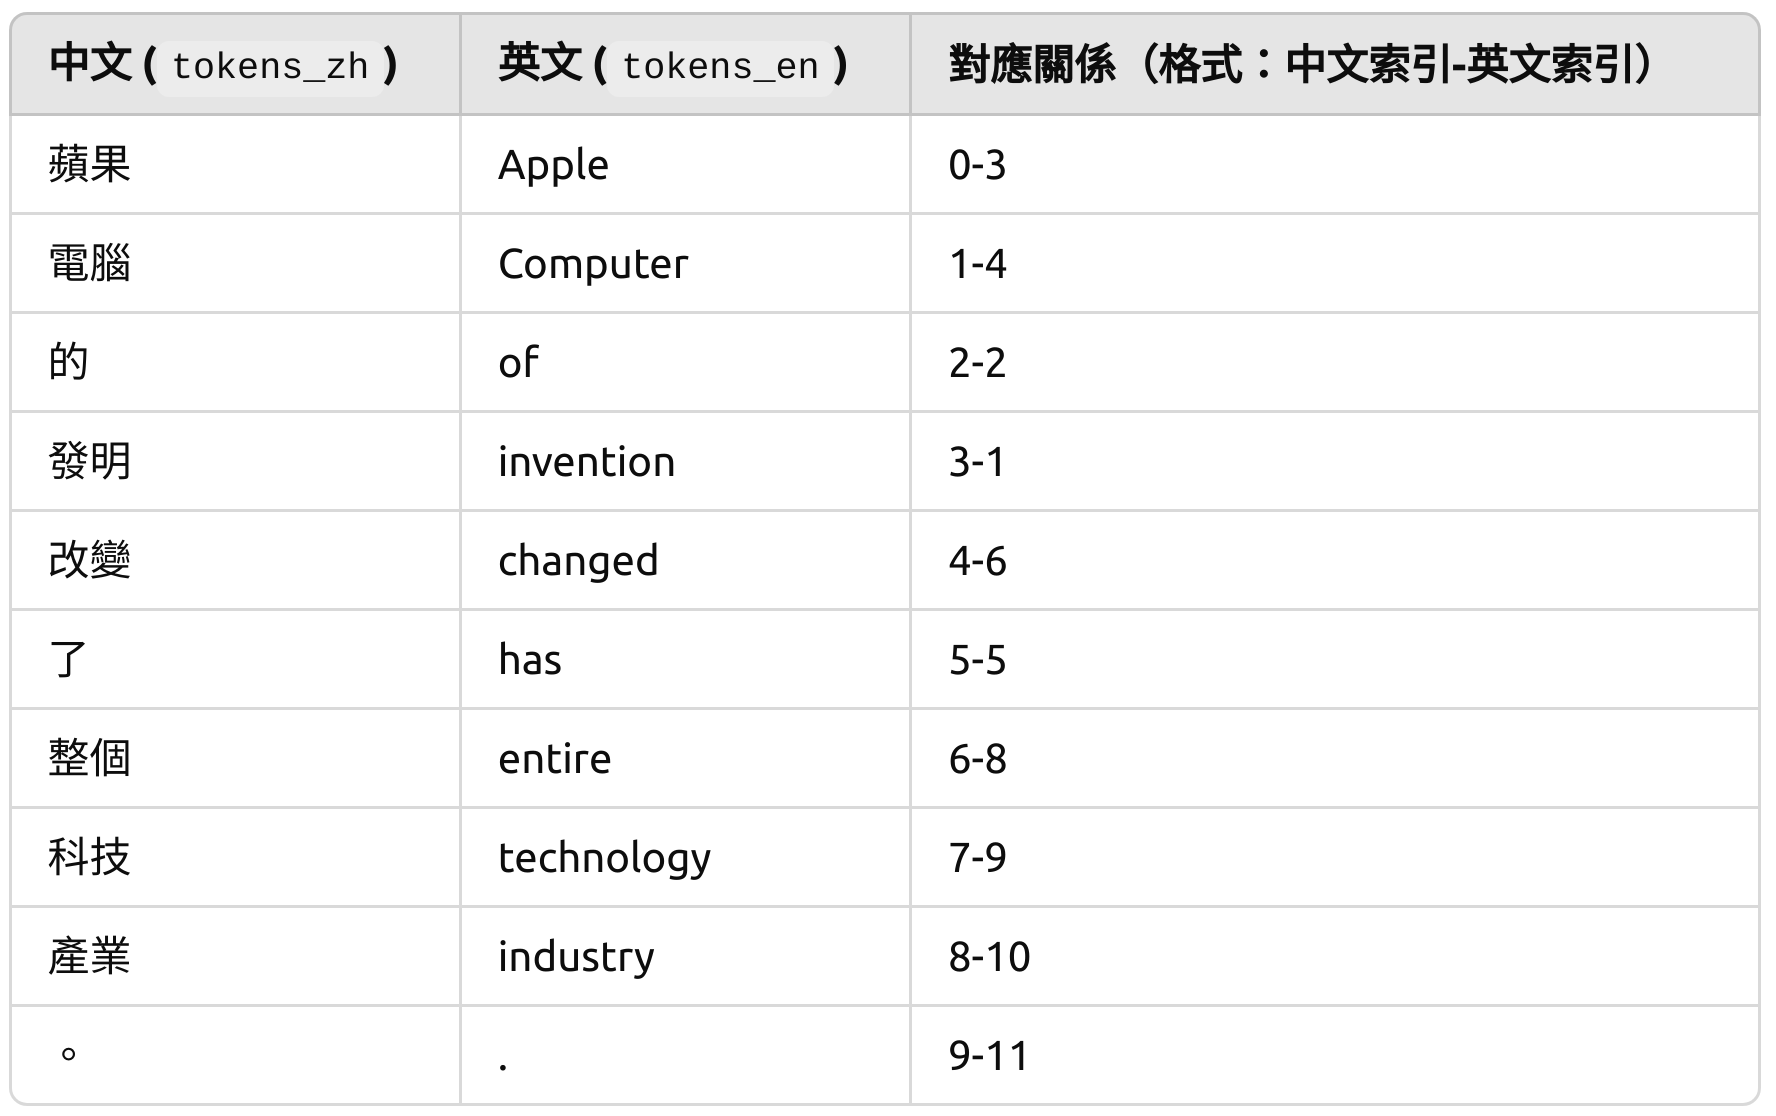

#### 將對齊結果列出來

In [17]:

# 生成對齊格式的列表
alignment_list = []
alignment_word_list = []

for zh_idx, en_idxs in alignment.items():
    for en_idx in en_idxs:
        alignment_list.append(f"{zh_idx}-{en_idx}")
        alignment_word_list.append(f"{tokens_zh[zh_idx]}-{tokens_en[en_idx]}")

# 將對齊結果列出來
alignment_str = " ".join(alignment_list)
alignment_word_str = "\n".join(alignment_word_list)

print("對齊結果 (Pharaoh format):")
print(alignment_str)
print("-"*20)
print(alignment_word_str)


對齊結果 (Pharaoh format):
0-3 1-4 2-2 3-1 4-6 5-5 6-8 7-9 8-10
--------------------
蘋果-Apple
電腦-Computer
的-of
發明-invention
改變-changed
了-has
整個-entire
科技-technology
產業-industry


# 修改流程

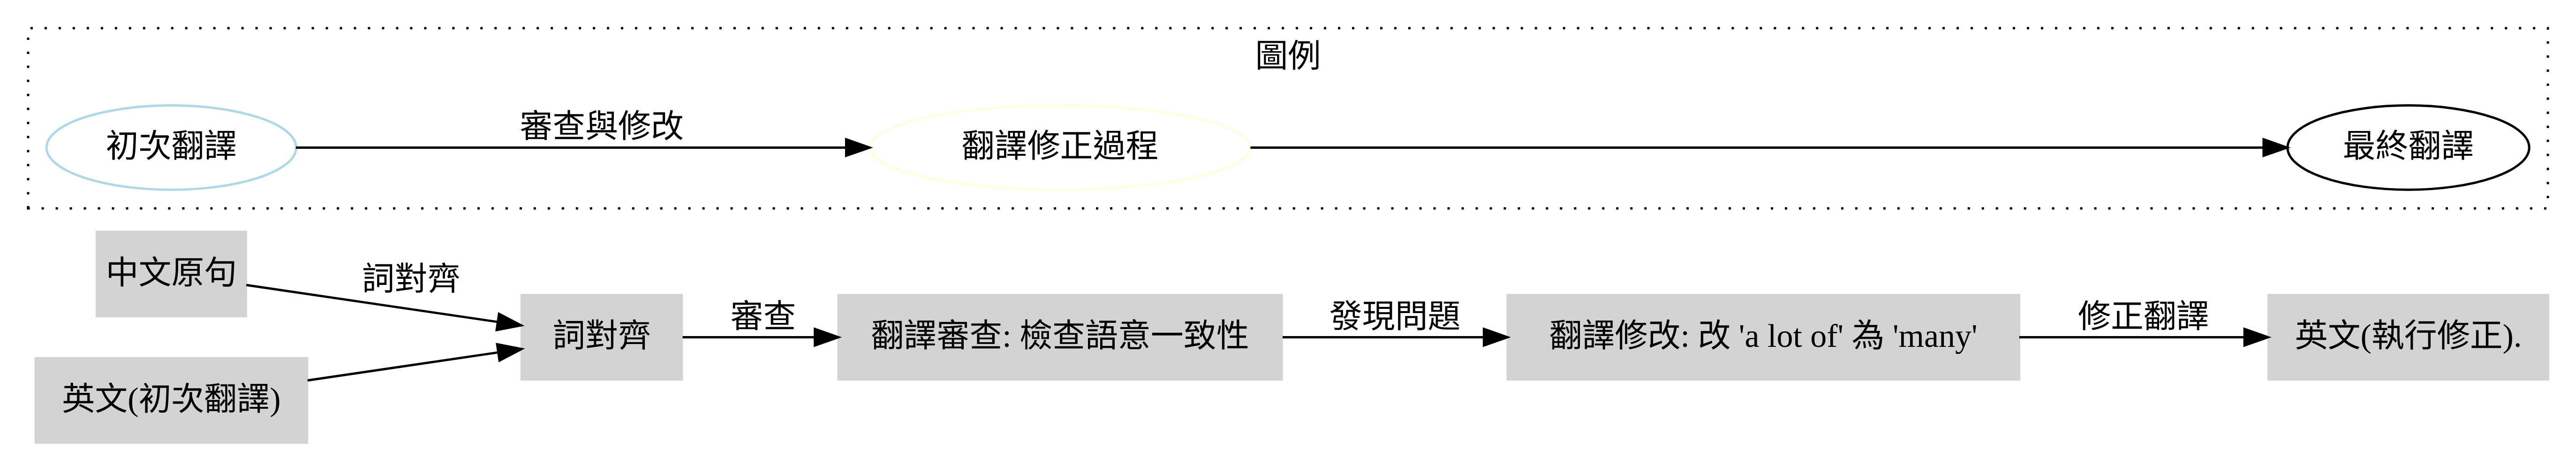

In [ ]:
# 定義中文和英文的詞彙列表
tokens_zh = ['張三', '在', '台北101', '前面', '拍', '了', '很多', '照片', '。']
tokens_en_initial = ['Zhang San', 'took', 'a', 'lot', 'of', 'photos', 'in', 'front', 'of', 'Taipei', '101', '.']

# 規則: 檢查並修正翻譯
def review_and_correct_translation(tokens_en):
    # 把 tokens 轉換為句子
    initial_translation = " ".join(tokens_en)

    # 輸出初始翻譯
    print("初始翻譯: ", initial_translation)

    # 修正邏輯: 將 "a lot of" 改為 "many"
    if "a lot of" in initial_translation:
        corrected_translation = initial_translation.replace("a lot of", "many")
        print("修正後的翻譯: ", corrected_translation)
    else:
        corrected_translation = initial_translation

    return corrected_translation

# 執行翻譯審查與修正
corrected_translation = review_and_correct_translation(tokens_en_initial)

# 結果展示
print("\n=== 翻譯修正流程 ===")
print("初始翻譯: " + " ".join(tokens_en_initial))
print("修正後翻譯: " + corrected_translation)


初始翻譯:  Zhang San took a lot of photos in front of Taipei 101 .
修正後的翻譯:  Zhang San took many photos in front of Taipei 101 .

=== 翻譯修正流程 ===
初始翻譯: Zhang San took a lot of photos in front of Taipei 101 .
修正後翻譯: Zhang San took many photos in front of Taipei 101 .
